In [1]:
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from picamera2 import Picamera2

In [2]:
!wget https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg

--2025-10-24 13:37:04--  https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 195.200.68.240, 2a02:ec80:700:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|195.200.68.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 279603 (273K) [image/jpeg]
Saving to: ‘Cat03.jpg.5’

Cat03.jpg.5         100%[===================>] 273.05K  --.-KB/s    in 0.1s    

2025-10-24 13:37:04 (2.17 MB/s) - ‘Cat03.jpg.5’ saved [279603/279603]



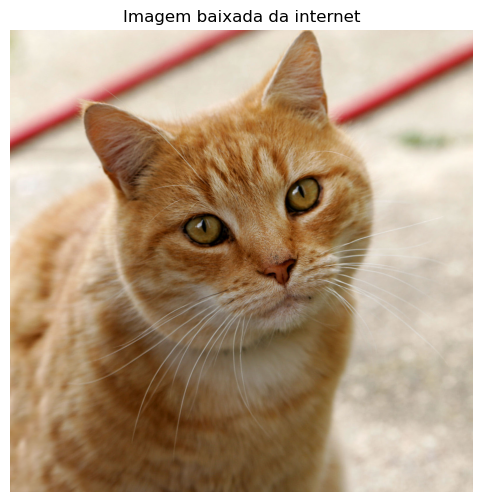

In [3]:
img_path = "Cat03.jpg"
title = "Imagem baixada da internet"
img = Image.open(img_path)

#Exibir a imagem
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(title)
plt.axis('off')  # Esconder os eixos
plt.show()

In [7]:
from picamera2 import Picamera2
import time

def capturar_imagens(num_capturas=10, intervalo=1, nome_base="captura"):
    """
    Inicializa a câmera, captura uma sequência de imagens e fecha a câmera de forma segura.

    Args:
        num_capturas (int): O número de fotos a serem tiradas. O padrão é 5.
        intervalo (int): O tempo de espera em segundos entre cada captura. O padrão é 2.
        nome_base (str): O prefixo para os nomes dos arquivos. O padrão é 'captura'.
                         As imagens serão salvas como 'nome_base_1.jpg', 'nome_base_2.jpg', etc.
    """
    # 1. Inicializar a câmera
    picam2 = Picamera2()
    picam2.start()
    print("Câmera inicializada.")

    # O bloco 'finally' garante que a câmera será fechada, não importa o que aconteça.
    try:
        # Espera inicial para a câmera estabilizar
        time.sleep(2)

        print(f"Iniciando a captura de {num_capturas} imagens com intervalo de {intervalo}s...")

        # 2. Loop para capturar várias imagens
        for i in range(num_capturas):
            nome_arquivo = f"{nome_base}_{i+1}.jpg"
            picam2.capture_file(nome_arquivo)
            print(f"Imagem capturada: {nome_arquivo}")
            
            # Esperar antes da próxima captura (se não for a última)
            if i < num_capturas - 1:
                time.sleep(intervalo)

        print("\nSequência de captura finalizada com sucesso.")

    finally:
        # 3. ESTE CÓDIGO SEMPRE SERÁ EXECUTADO!
        print("Fechando a câmera...")
        picam2.stop()
        picam2.close()
        print("Câmera fechada com sucesso.")


# --- EXEMPLOS DE COMO USAR A FUNÇÃO ---

# Exemplo 1: Usando os valores padrão (10 fotos, intervalo de 1s, nome base 'captura')
print("--- Iniciando a primeira sessão de captura ---")
capturar_imagens()
print("------------------------------------------\n")

# Adiciona uma pausa para não começar a próxima captura imediatamente
time.sleep(5) 

# Exemplo 2: Personalizando os argumentos (10 fotos, intervalo de 0.5s, nome base 'teste_sala')
print("--- Iniciando a segunda sessão de captura ---")
capturar_imagens(num_capturas=10, intervalo=.5, nome_base="teste_sala")
print("-------------------------------------------")

--- Iniciando a primeira sessão de captura ---
Câmera inicializada.


[0:08:26.754743591] [887]  INFO Camera camera_manager.cpp:297 libcamera v0.0.5+83-bde9b04f
[0:08:27.424135285] [887]  INFO Camera camera.cpp:1033 configuring streams: (0) 640x480-MJPEG


Iniciando a captura de 10 imagens com intervalo de 1s...
Imagem capturada: captura_1.jpg
Imagem capturada: captura_2.jpg
Imagem capturada: captura_3.jpg
Imagem capturada: captura_4.jpg
Imagem capturada: captura_5.jpg
Imagem capturada: captura_6.jpg
Imagem capturada: captura_7.jpg
Imagem capturada: captura_8.jpg
Imagem capturada: captura_9.jpg
Imagem capturada: captura_10.jpg

Sequência de captura finalizada com sucesso.
Fechando a câmera...
Câmera fechada com sucesso.
------------------------------------------

--- Iniciando a segunda sessão de captura ---


[0:08:44.582200956] [956]  INFO Camera camera_manager.cpp:297 libcamera v0.0.5+83-bde9b04f
[0:08:45.255338632] [956]  INFO Camera camera.cpp:1033 configuring streams: (0) 640x480-MJPEG


Câmera inicializada.
Iniciando a captura de 10 imagens com intervalo de 0.5s...
Imagem capturada: teste_sala_1.jpg
Imagem capturada: teste_sala_2.jpg
Imagem capturada: teste_sala_3.jpg
Imagem capturada: teste_sala_4.jpg
Imagem capturada: teste_sala_5.jpg
Imagem capturada: teste_sala_6.jpg
Imagem capturada: teste_sala_7.jpg
Imagem capturada: teste_sala_8.jpg
Imagem capturada: teste_sala_9.jpg
Imagem capturada: teste_sala_10.jpg

Sequência de captura finalizada com sucesso.
Fechando a câmera...
Câmera fechada com sucesso.
-------------------------------------------
